In [1]:
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
import json
from qiskit.quantum_info import SparsePauliOp
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters

2025-06-02 04:14:27,958	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
# Extract classical results
cs_dir = "../classical_search/cs_res/"

def relabel_turns(turns: str) -> str:
    """Relabels the turns from the classical search to the ones used in the quantum search."""
    mapping = {
        "0": "0",
        "1": "2", 
        "2": "4",
        "3": "6",
        "4": "8",
        "5": "a",
        "6": "1",
        "7": "3",
        "8": "5",
        "9": "7",
        "a": "9",
        "b": "b"
    }
    return "".join([mapping[turn] for turn in turns])


def load_top_cls_solns(file_name: str) -> list:
    top_cls_turns = []
    with open(cs_dir + file_name, "r") as file:
        data = file.read()
        # Split by line
        data_by_line = data.split("\n")
        for line in data_by_line:
            if len(line.split("\t")) == 2:
                [energy, turns] = line.split("\t")
                top_cls_turns.append([relabel_turns(turns), float(energy)])
    return top_cls_turns

In [3]:
def convert_bitstring_to_turns(soln_bitstring: str, main_seq: str) -> str:
    """Converts a solution bitstring (given by the quantum algorithm) to the
    turns."""
    encoding = {
        "0000": "0",
        "0011": "1",
        "1100": "2",
        "1111": "3",
        "1001": "4",
        "0101": "5",
        "1010": "6",
        "0110": "7",
        "1000": "8",
        "0100": "9",
        "1011": "a",
        "0111": "b",
        "0001": "x", # unphysical
        "0010": "x", # unphysical
        "1101": "x", # unphysical
        "1110": "x", # unphysical
    }
    peptide_len = len(main_seq)
    config_bitstring = soln_bitstring[-(4 * peptide_len - 10) :]
    # Add the first 4 bits corresponding to the fixed first turn (0000)
    full_config_bitstring = config_bitstring + "0000"
    # Add the two qubits at positions 6 & 7 from the right (00)
    full_config_bitstring = (
        full_config_bitstring[:-6] + "00" + full_config_bitstring[-6:]
    )
    # Reverse the bitstring
    full_config_bitstring = full_config_bitstring[::-1]
    length_turns = len(full_config_bitstring) // 4
    turns = ""
    for i in range(length_turns):
        turn = full_config_bitstring[i * 4 : (i + 1) * 4]
        turns += encoding[turn]
    # Reverse the turns
    return turns[::-1]

### KLVFFA_6AAs MPS run, interval4 (3pi/2, 2pi) initial params, 10 loops
- $R^2 = 1$
- 100k shots
- 500 COBYLA iterations

In [5]:
import os
# Function to load the qubit_op from the existing directory

def load_qubit_op(main_seq, r2_threshold, ham_dir="fcc_hamilts"):
    """
    Load the Hamiltonian operator from a JSON file.
    
    Args:
        main_seq (str): The amino acid sequence (e.g., "KLVFFA")
        r2_threshold (float): Threshold for R2 filtering
        ham_dir (str): Directory where the Hamiltonian is stored
    
    Returns:
        SparsePauliOp: The qubit Hamiltonian operator
    """
    file_name = f"{main_seq}_{len(main_seq)}AAs_R2_{int(r2_threshold * 1000)}.json"
    os.makedirs(ham_dir, exist_ok=True)
    file_path = os.path.join(ham_dir, file_name)
    
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Hamiltonian not found at: {file_path}")
    
    print(f"✅ Loaded Hamiltonian from: {file_path}")
    
    with open(file_path, "r") as f:
        data = json.load(f)
        num_qubits = data["num_qubits"]
        sparse_op_list = [(label, coeff) for label, coeff in data["sparse_list"]]
    
    qubit_op = SparsePauliOp.from_list(sparse_op_list, num_qubits=num_qubits)
    return qubit_op

main_seq = "KLVFFA" # 6MVZ
qubit_op = load_qubit_op(main_seq, r2_threshold=1.0)
print(qubit_op.size)

✅ Loaded Hamiltonian from: fcc_hamilts/KLVFFA_6AAs_R2_1000.json
18133


In [8]:
# Create dictionaries to store metadata and opt_results
all_metadata = {}
all_opt_results = {}

# Target directory containing the result folders
results_dir = "../res/cheb_mps"

# Collect and sort all result directories
all_runs = sorted(
    [d for d in os.listdir(results_dir) if d.startswith("KLVFFA_") and os.path.isdir(os.path.join(results_dir, d))]
)

# Sort based on timestamp inside the folder names
all_runs.sort(key=lambda name: name.split("_")[1])  # sort by timestamp component

# Load each run, renaming them as mps_run{i}
for i, run_name in enumerate(all_runs):
    run_path = os.path.join(results_dir, run_name)
    metadata_path = os.path.join(run_path, "metadata.json")
    opt_res_path = os.path.join(run_path, "opt_results.json")

    with open(metadata_path, "r") as f:
        all_metadata[f"mps_run{i}"] = json.load(f)

    with open(opt_res_path, "r") as f:
        all_opt_results[f"mps_run{i}"] = json.load(f)

print("✅ Loaded metadata and optimization results for all 11 MPS runs.")


✅ Loaded metadata and optimization results for all 11 MPS runs.


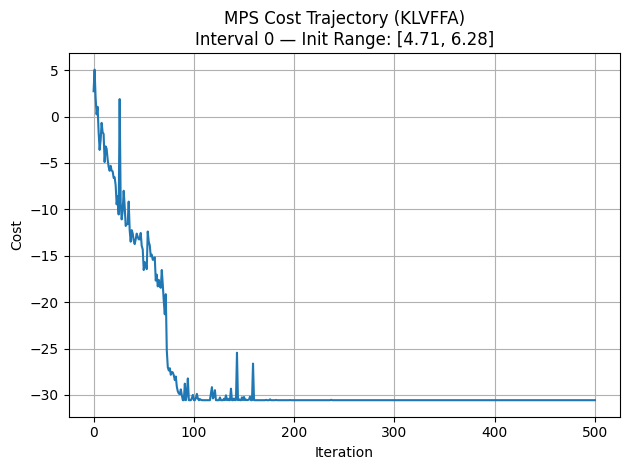

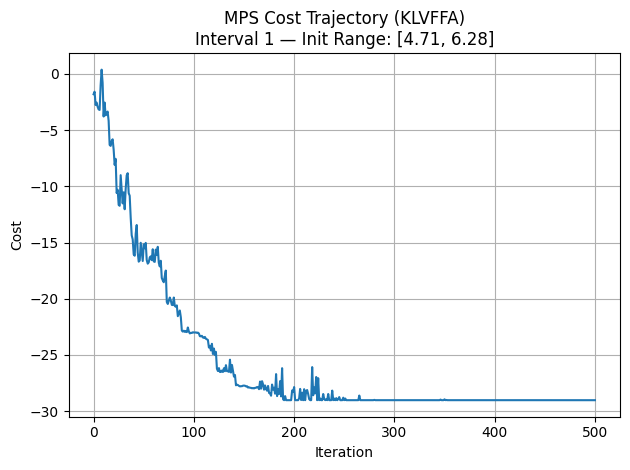

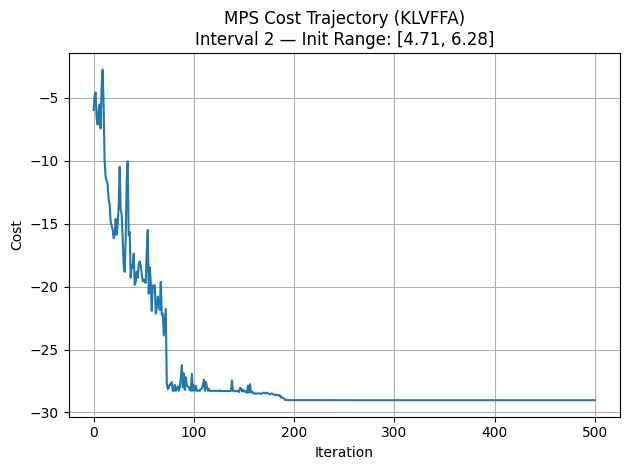

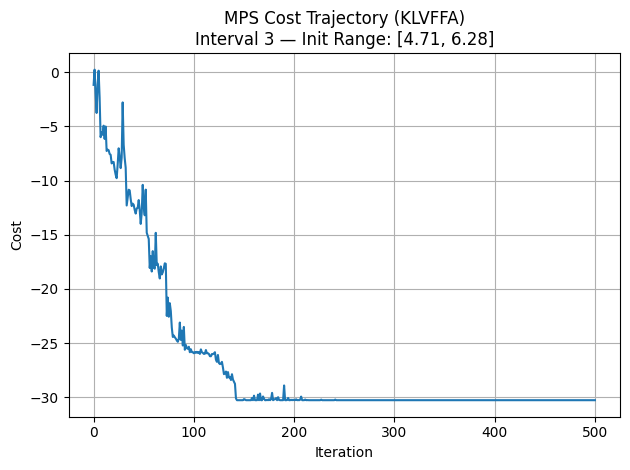

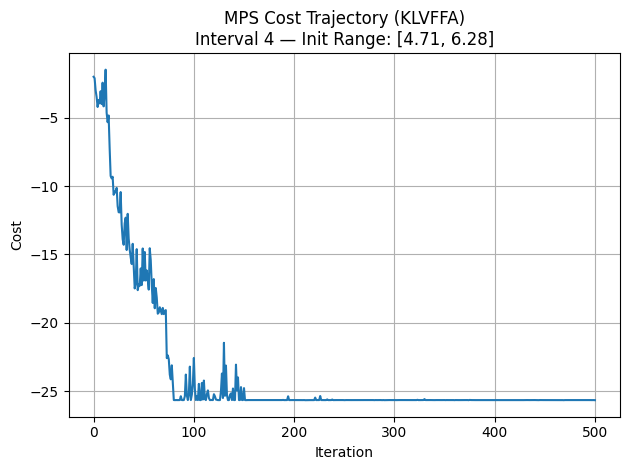

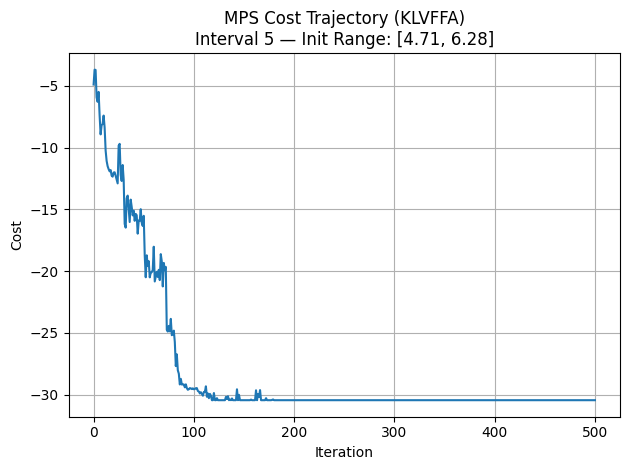

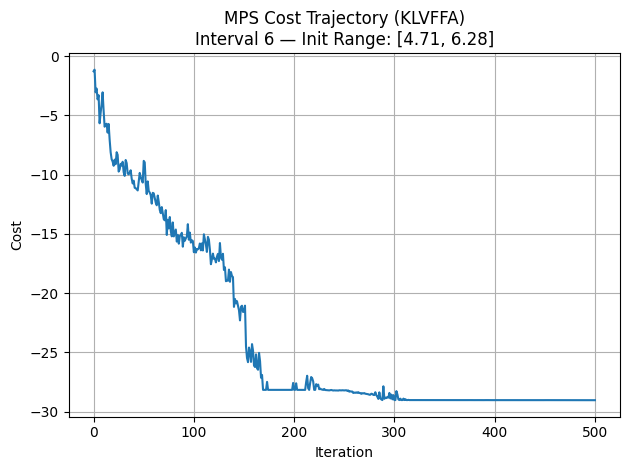

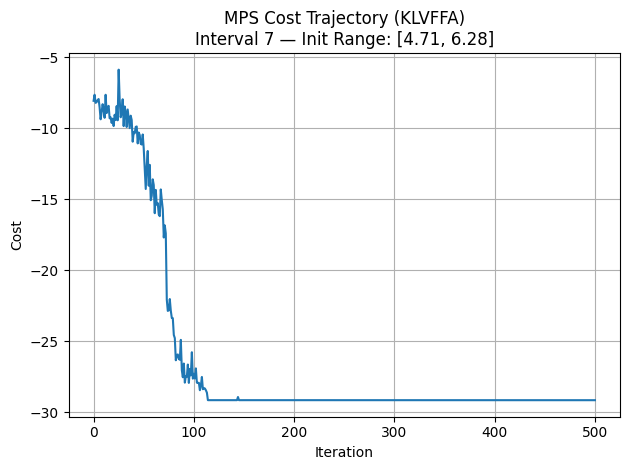

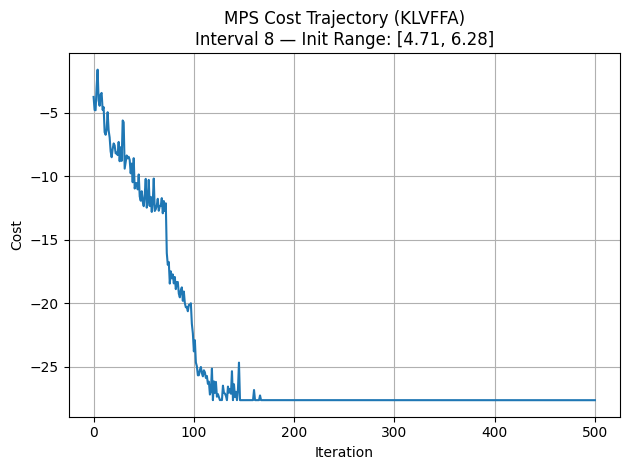

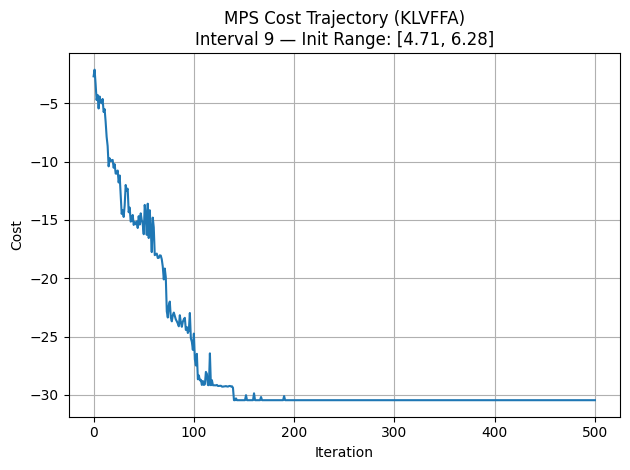

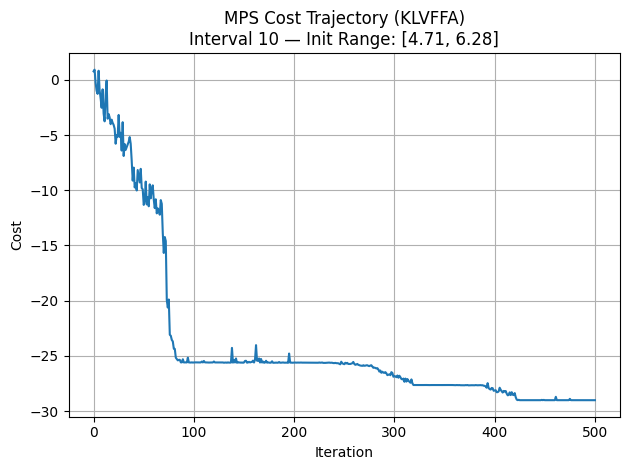

In [10]:
import matplotlib.pyplot as plt

for i in range(11):
    opt_res = all_opt_results[f"mps_run{i}"]
    metadata = all_metadata[f"mps_run{i}"]

    plt.figure()
    plt.plot(opt_res["cost_trajectory"])
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.title(f"MPS Cost Trajectory (KLVFFA)\nInterval {i} — Init Range: {metadata['init_param_interval']}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [11]:
# Dictionary to store top 100 solutions per run
top_mps_solns_by_run = {}

for i in range(11):
    key = f"mps_run{i}"
    opt_res = all_opt_results[key]
    metadata = all_metadata[key]

    top_100 = opt_res["top_solutions"][:100]

    top_mps_solns = [
        [convert_bitstring_to_turns(bitstring, metadata["main_seq"]), bitstring, energy]
        for bitstring, energy in top_100
    ]

    top_mps_solns_by_run[key] = top_mps_solns

# Example: preview first 10 results from mps_run0
top_mps_solns_by_run["mps_run0"][:10]


[['97490', '110011110100100110100110', -30.570074742040894],
 ['81490', '101101110100011100100110', -30.451576447537764],
 ['07490', '100111010100000110100110', -30.129001685658622],
 ['97490', '110011010100100110100110', -29.260074742040892],
 ['81490', '101101010100011100100110', -29.14157644753777],
 ['07a90', '101110010100000110110110', -29.139998369934172],
 ['41820', '101011010010011100000111', -29.01449062557885],
 ['97a90', '111010010100100110110110', -28.271634111328986],
 ['68590', '111010010101010001101010', -28.268174889758242],
 ['90b90', '111010001100100000111010', -28.267254122741164]]

In [12]:
for i in range(11):
    key = f"mps_run{i}"
    top_mps_solns = top_mps_solns_by_run[key]

    # Convert each turn sequence (a list) to a tuple so it can go in a set
    unique_turns = set(tuple(sol[0]) for sol in top_mps_solns)

    print(f"{key} — Init Range {all_metadata[key]['init_param_interval']}: {len(unique_turns)} unique turn sequences")


mps_run0 — Init Range [4.71, 6.28]: 46 unique turn sequences
mps_run1 — Init Range [4.71, 6.28]: 57 unique turn sequences
mps_run2 — Init Range [4.71, 6.28]: 45 unique turn sequences
mps_run3 — Init Range [4.71, 6.28]: 49 unique turn sequences
mps_run4 — Init Range [4.71, 6.28]: 67 unique turn sequences
mps_run5 — Init Range [4.71, 6.28]: 42 unique turn sequences
mps_run6 — Init Range [4.71, 6.28]: 53 unique turn sequences
mps_run7 — Init Range [4.71, 6.28]: 51 unique turn sequences
mps_run8 — Init Range [4.71, 6.28]: 56 unique turn sequences
mps_run9 — Init Range [4.71, 6.28]: 53 unique turn sequences
mps_run10 — Init Range [4.71, 6.28]: 49 unique turn sequences


In [13]:
# Get top 100 solutions from classical search results
top_cls_solns = load_top_cls_solns(f"{len(metadata['main_seq'])}AA_{metadata['main_seq']}_topobj.txt")[:100]
top_cls_solns[:10]

[['97490', -30.57],
 ['a9720', -30.55],
 ['8b520', -30.55],
 ['70b90', -30.45],
 ['81490', -30.45],
 ['31a20', -30.43],
 ['31820', -30.43],
 ['2b580', -30.43],
 ['9a180', -30.43],
 ['5b580', -30.33]]

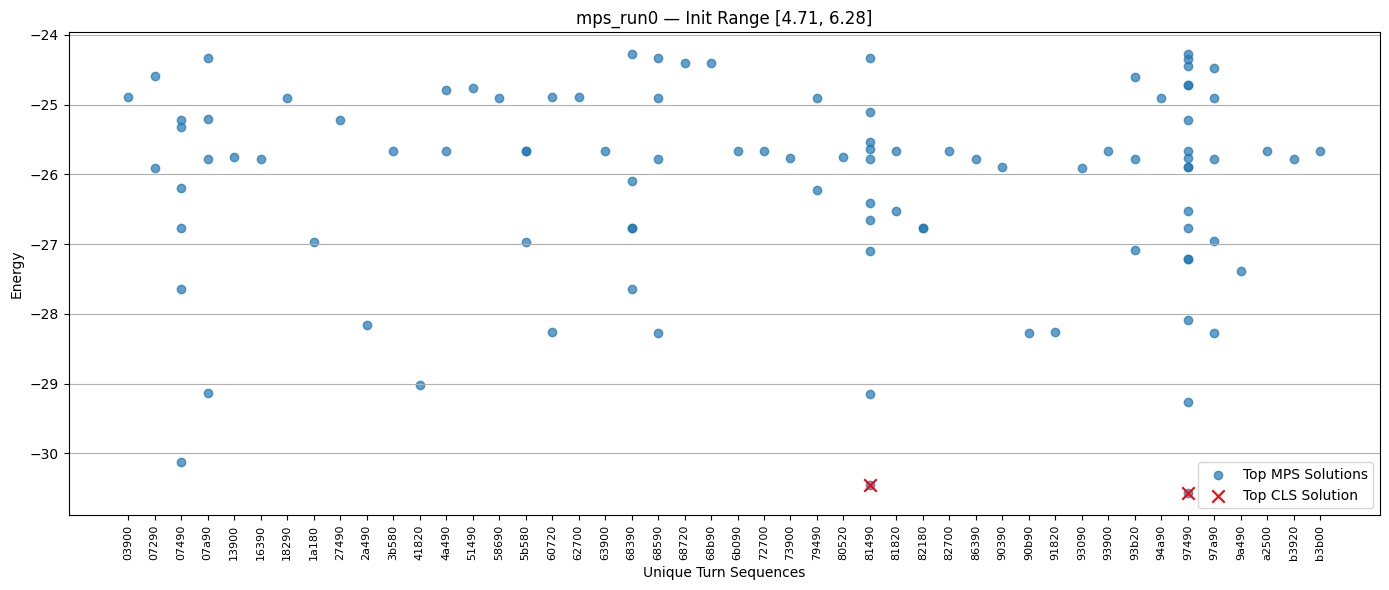

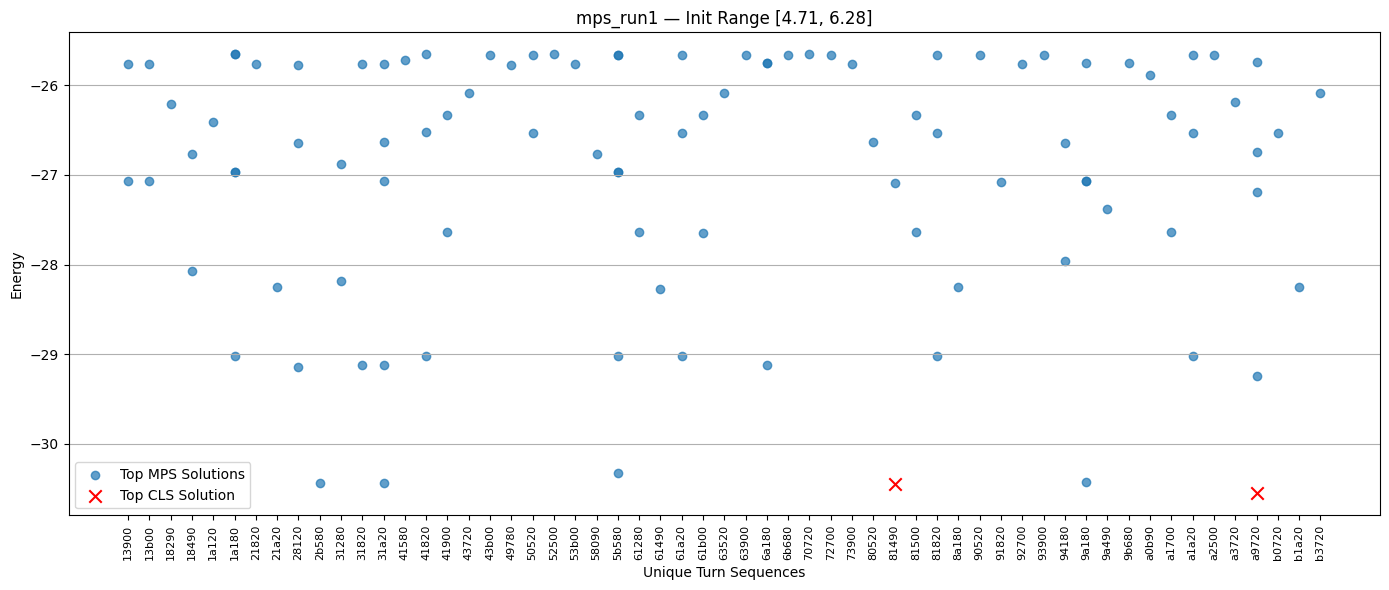

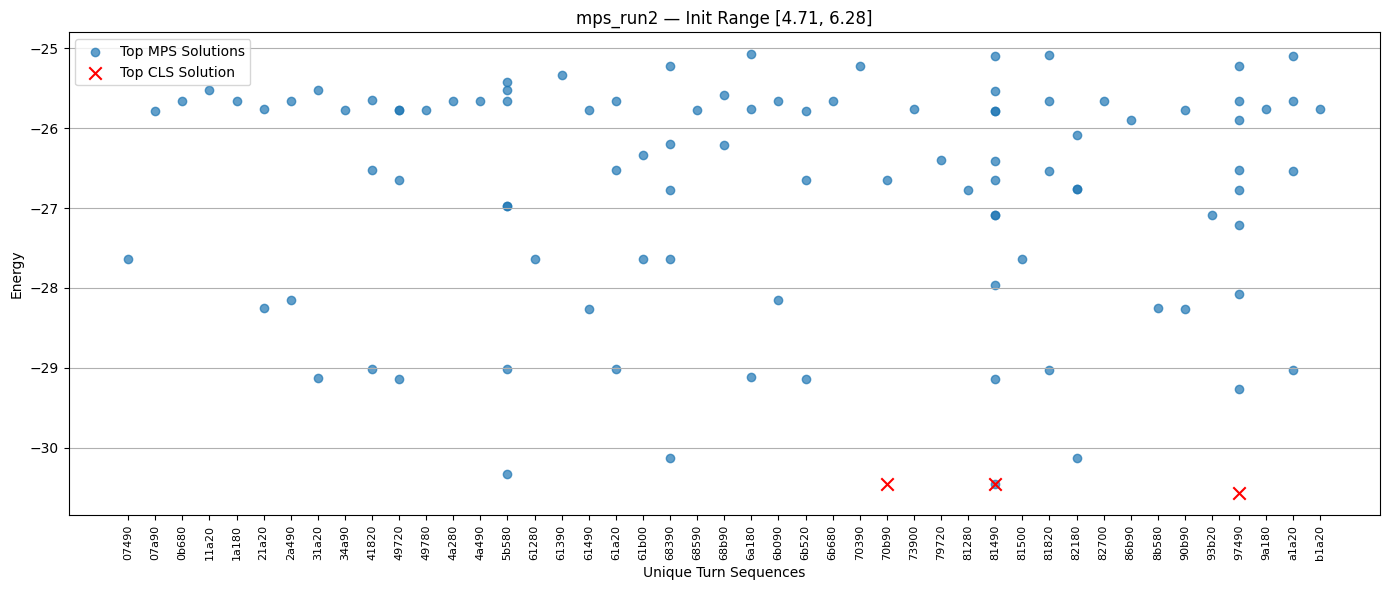

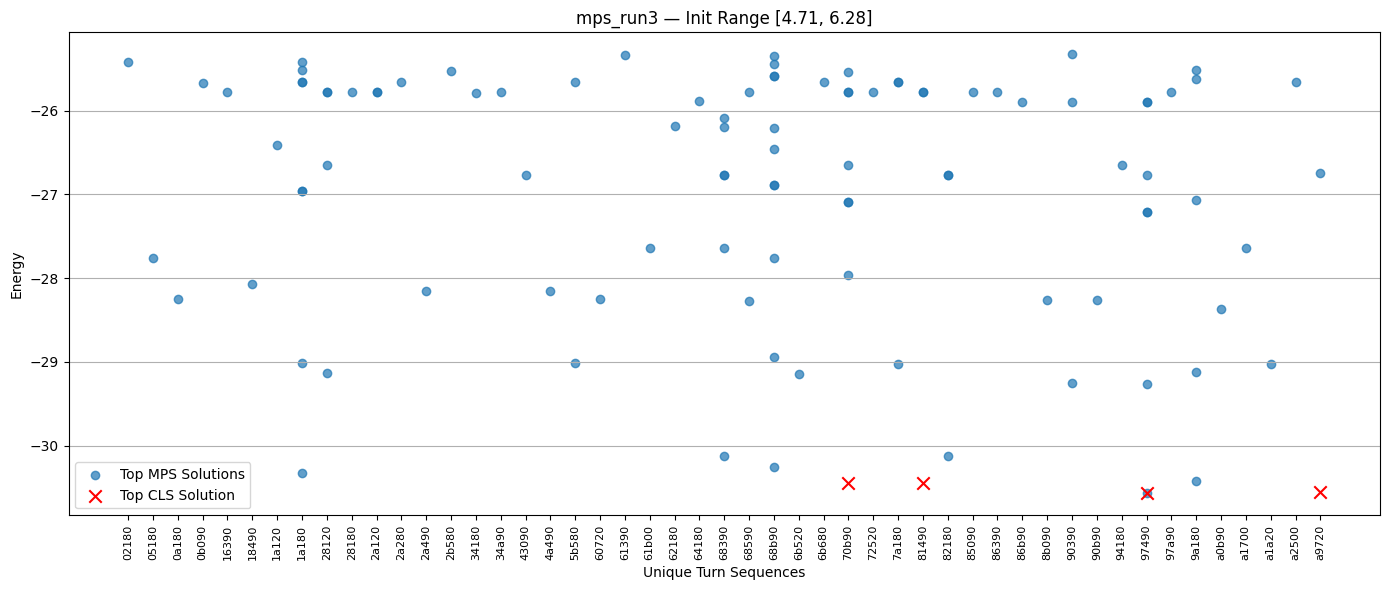

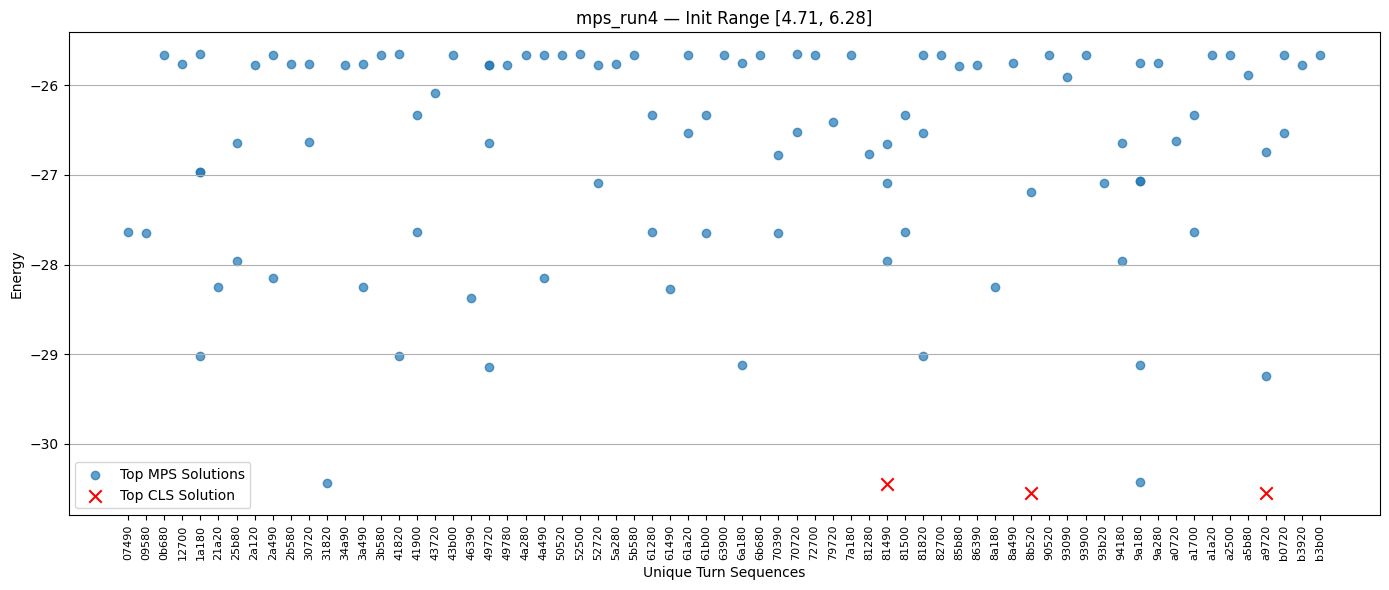

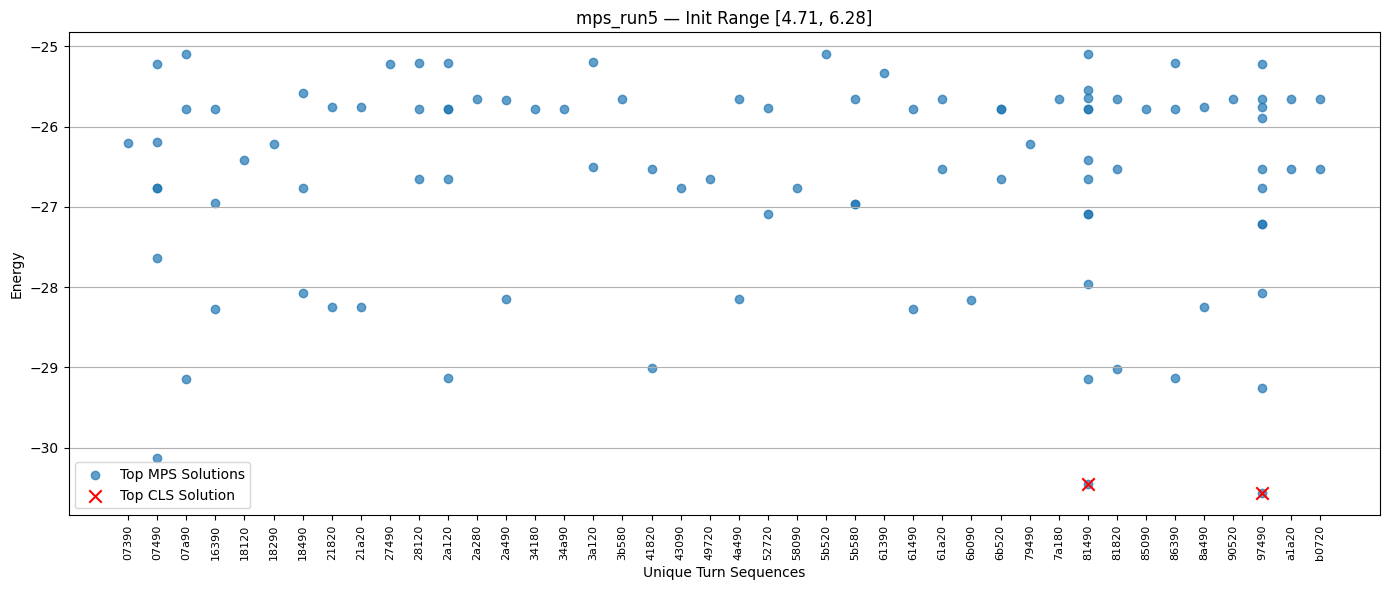

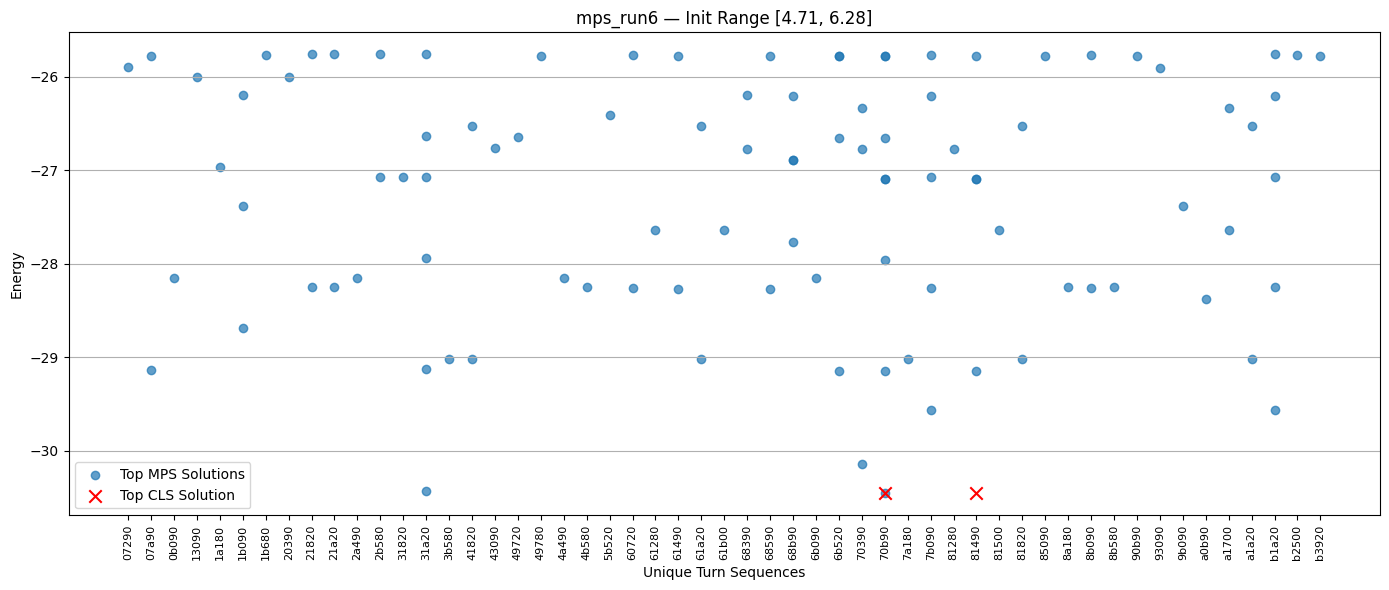

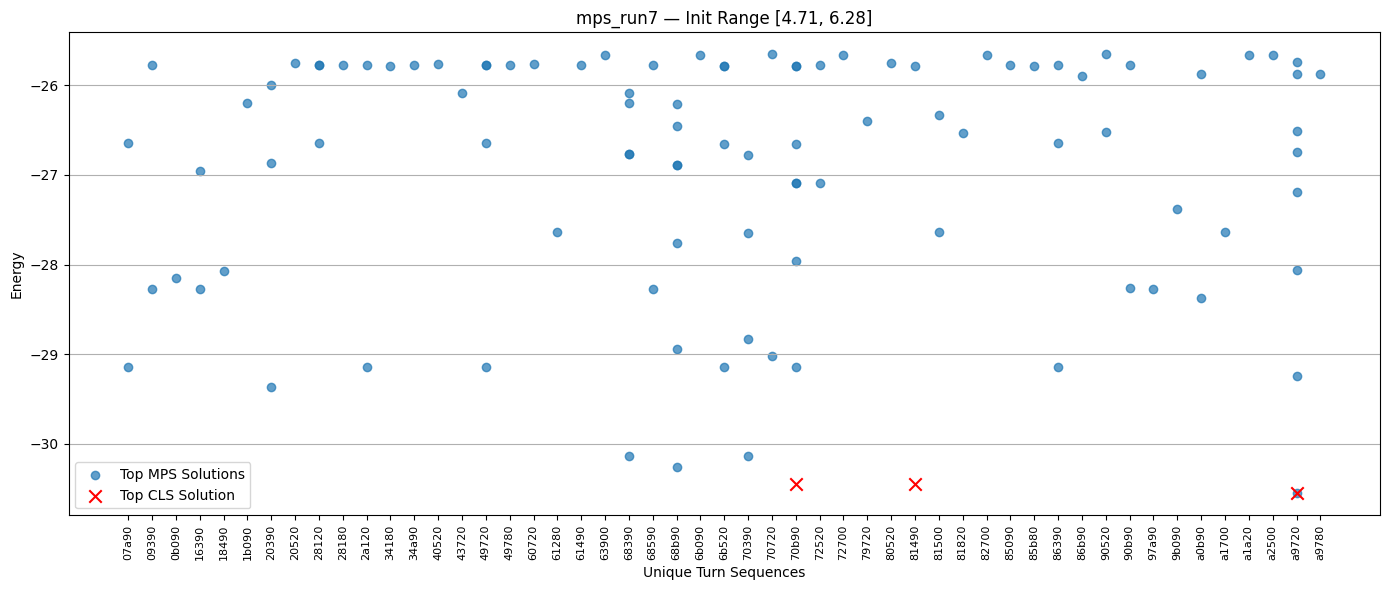

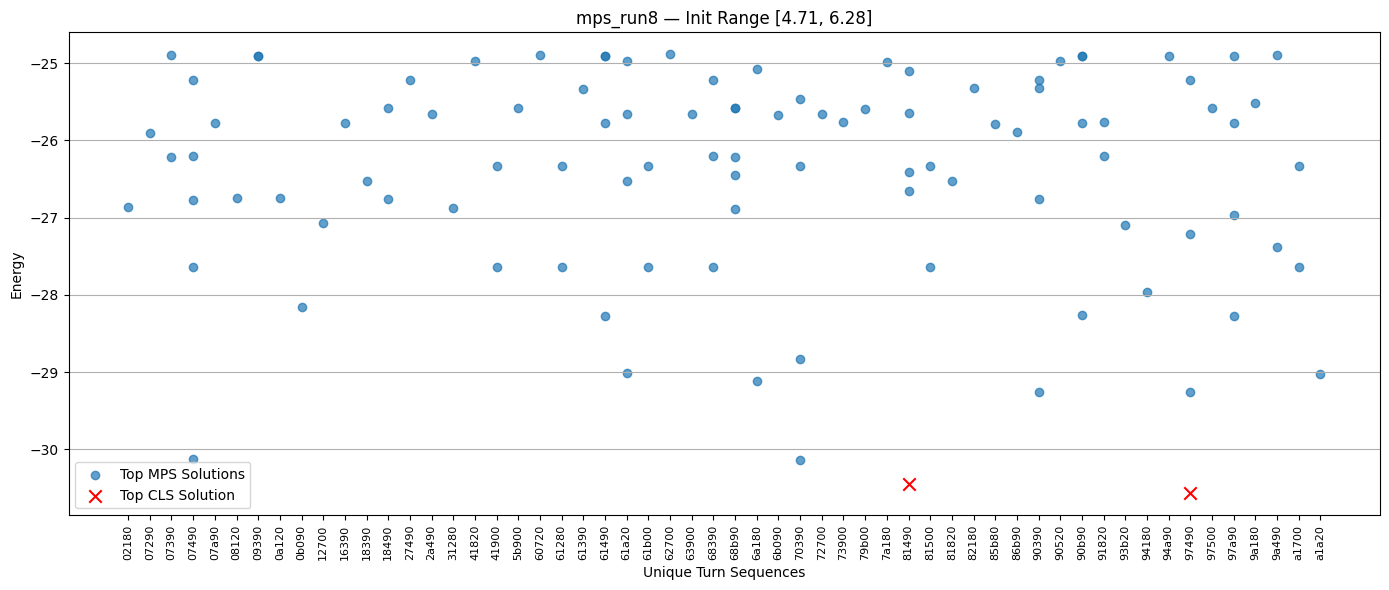

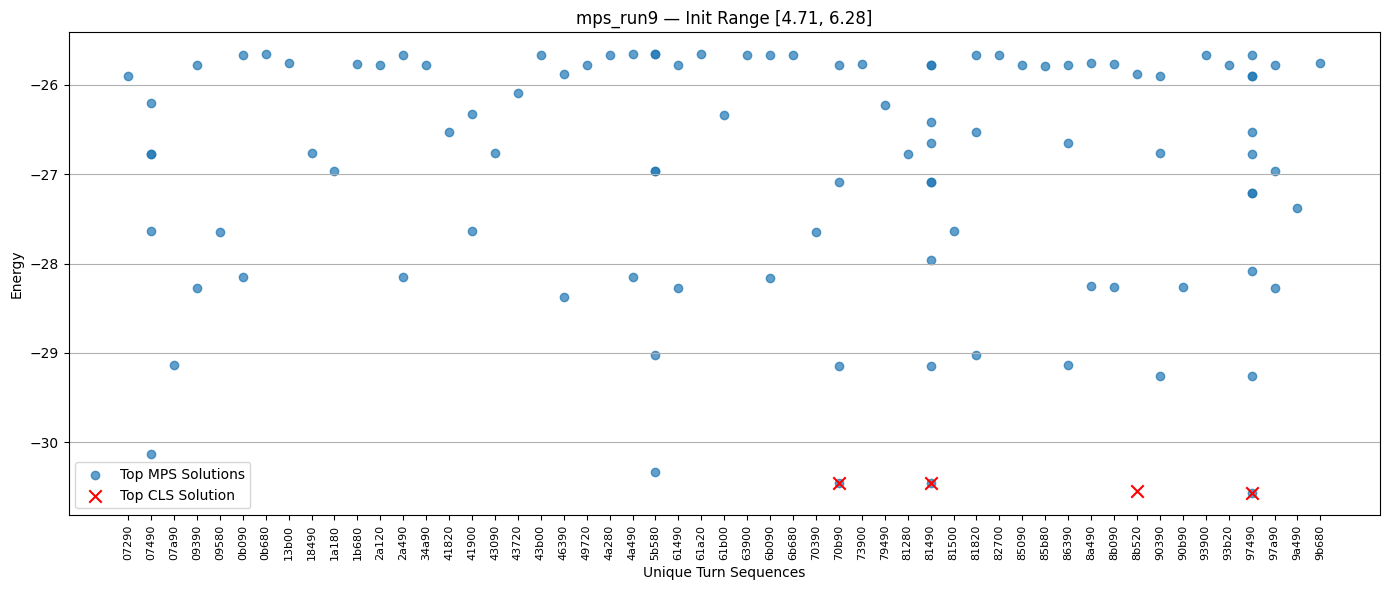

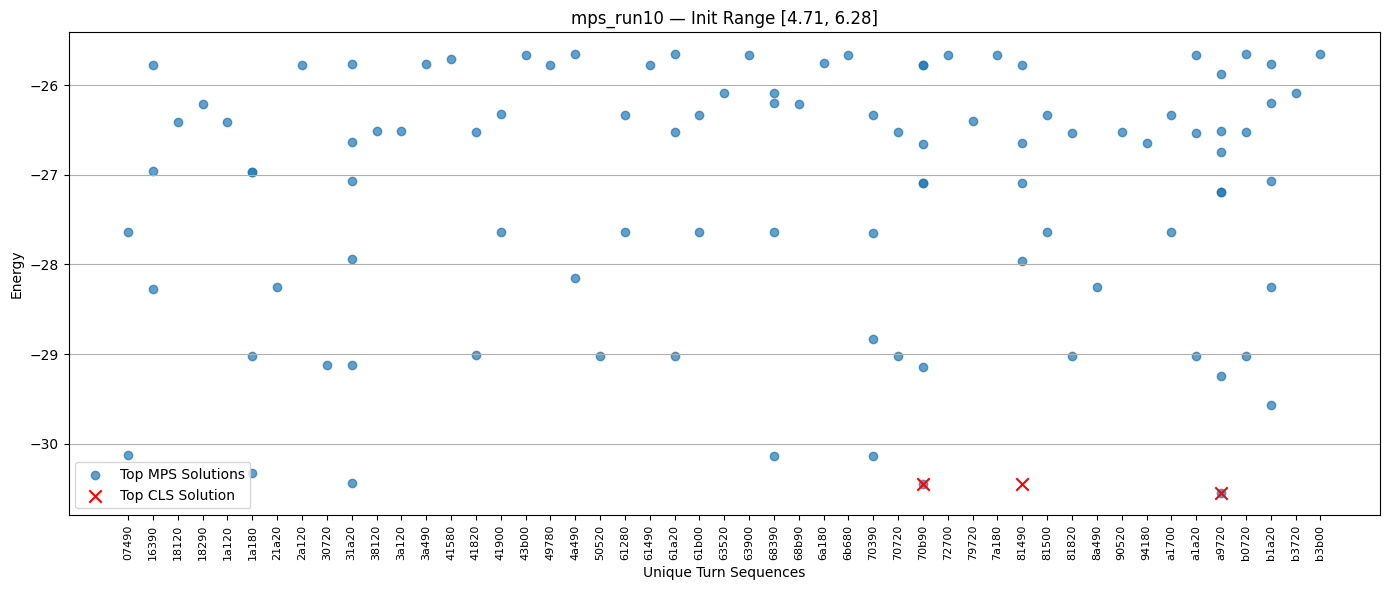

In [20]:
from collections import defaultdict

for i in range(11):
    key = f"mps_run{i}"
    top_mps_solns = top_mps_solns_by_run[key]
    metadata = all_metadata[key]
    
    turn_seq_energy_dict = defaultdict(list)

    for turn_seq, bitstring, energy in top_mps_solns:
        turn_seq_str = ''.join(turn_seq)
        turn_seq_energy_dict[turn_seq_str].append(energy)
    
    sorted_turns = sorted(turn_seq_energy_dict.keys())
    
    x_vals = []
    y_vals = []

    for idx, turn in enumerate(sorted_turns):
        energies = turn_seq_energy_dict[turn]
        x_vals.extend([idx] * len(energies))
        y_vals.extend(energies)

    turn_seq_to_index = {turn_seq: idx for idx, turn_seq in enumerate(sorted_turns)}

    plt.figure(figsize=(14, 6))
    plt.scatter(x_vals, y_vals, alpha=0.7, label='Top MPS Solutions')

    # Only plot top 5 classical solutions
    for turn_str, energy in top_cls_solns[:5]:
        scaled_energy = energy   # adjust scaling if needed
        if turn_str in turn_seq_to_index:
            x_idx = turn_seq_to_index[turn_str]
            plt.scatter(x_idx, scaled_energy, color='red', marker='x', s=80, label='Top CLS Solution')

    # Deduplicate legend
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_labels = dict(zip(labels, handles))
    plt.legend(unique_labels.values(), unique_labels.keys())

    # Final plot formatting
    plt.xticks(ticks=range(len(sorted_turns)), labels=sorted_turns, rotation=90, fontsize=8)
    plt.xlabel("Unique Turn Sequences")
    plt.ylabel("Energy")
    plt.title(f"{key} — Init Range {metadata['init_param_interval']}")
    plt.tight_layout()
    plt.grid(True, axis='y')
    plt.show()


In [21]:
from fcc import ProteinShapeDecoder, ProteinShapeFileGen
from fcc.fcc_protein_shape import turns_to_bitstring
from fcc.measurement_utils import _evaluate_sparsepauli

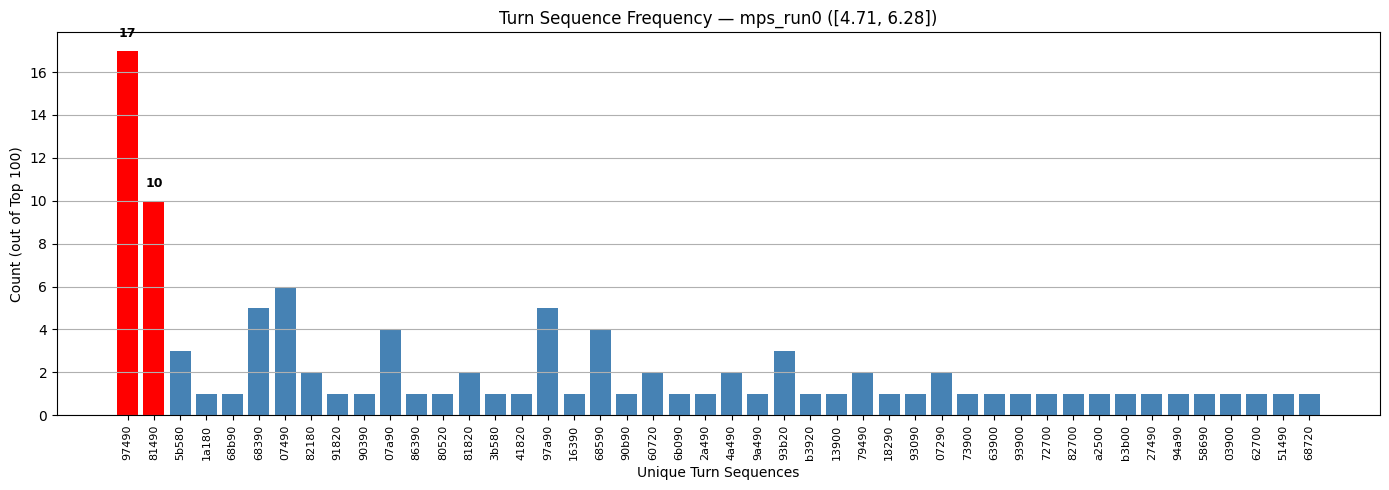

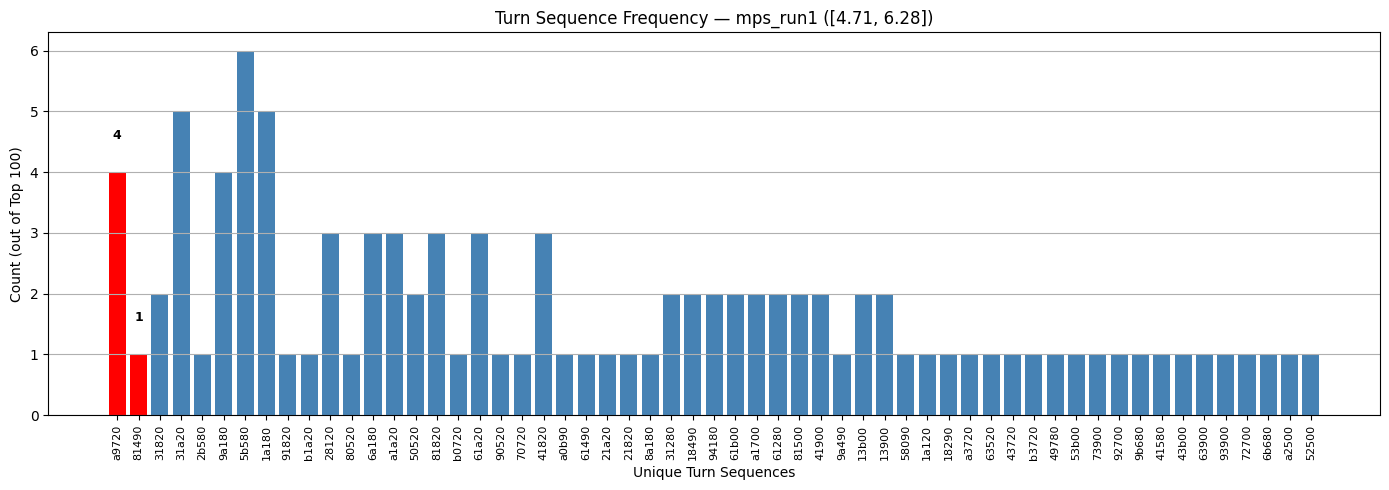

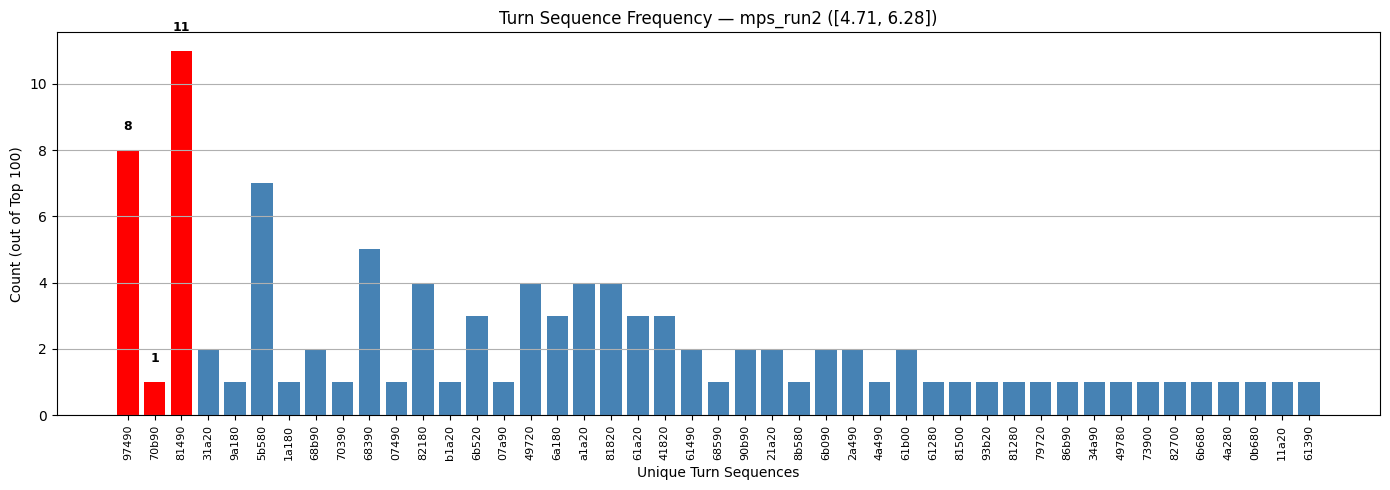

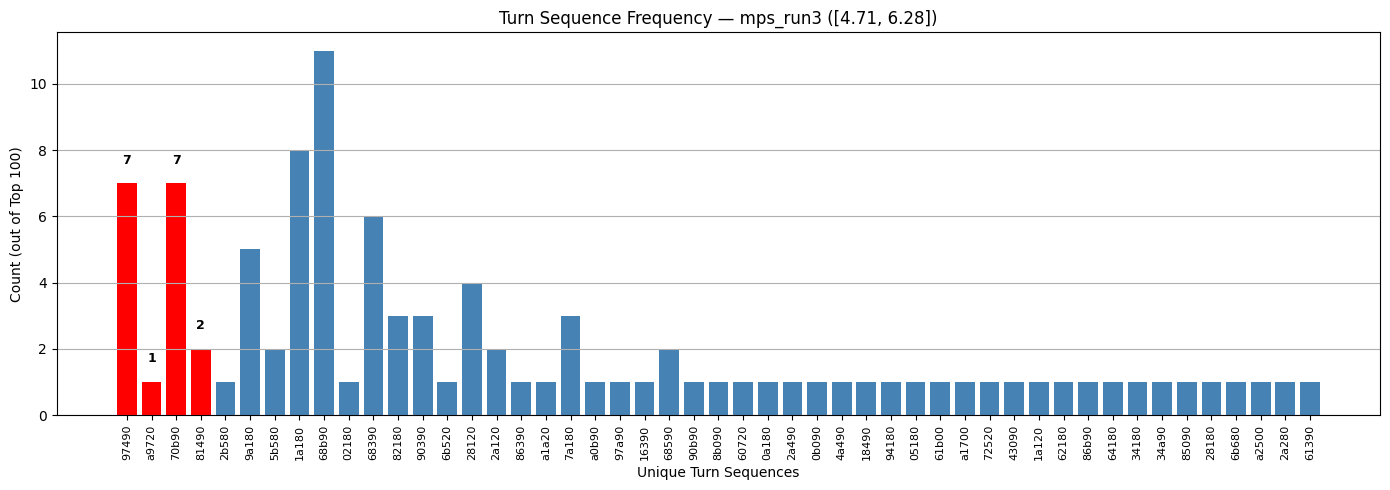

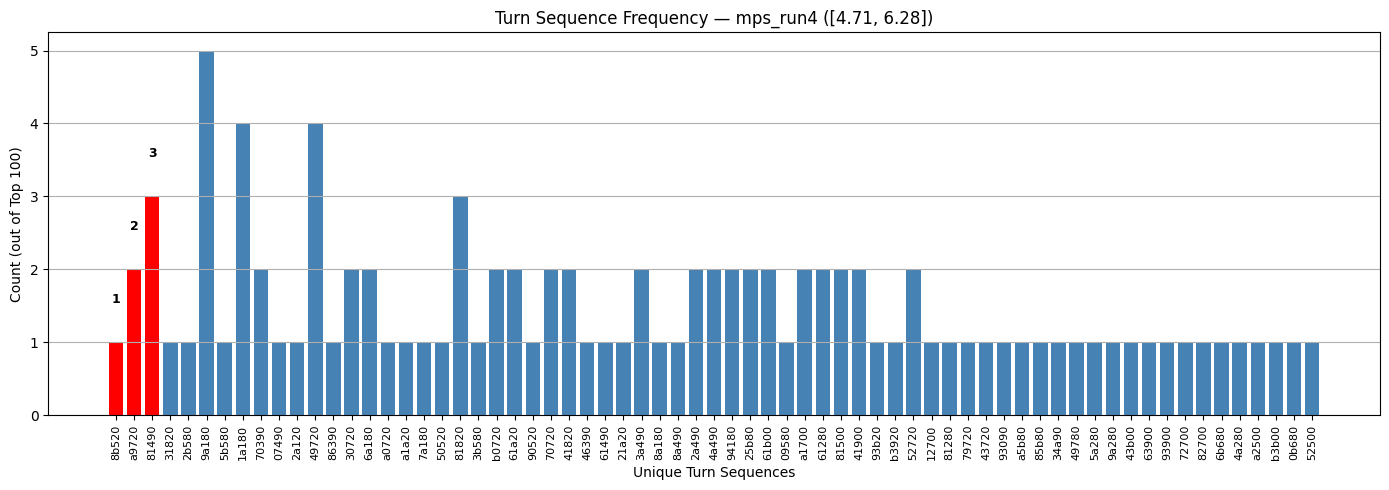

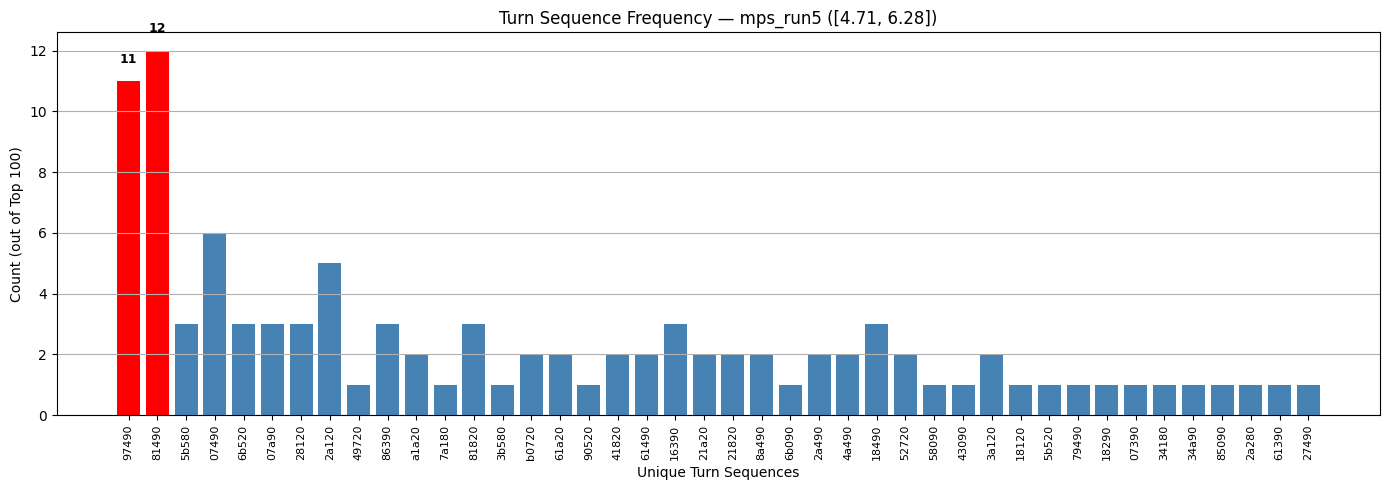

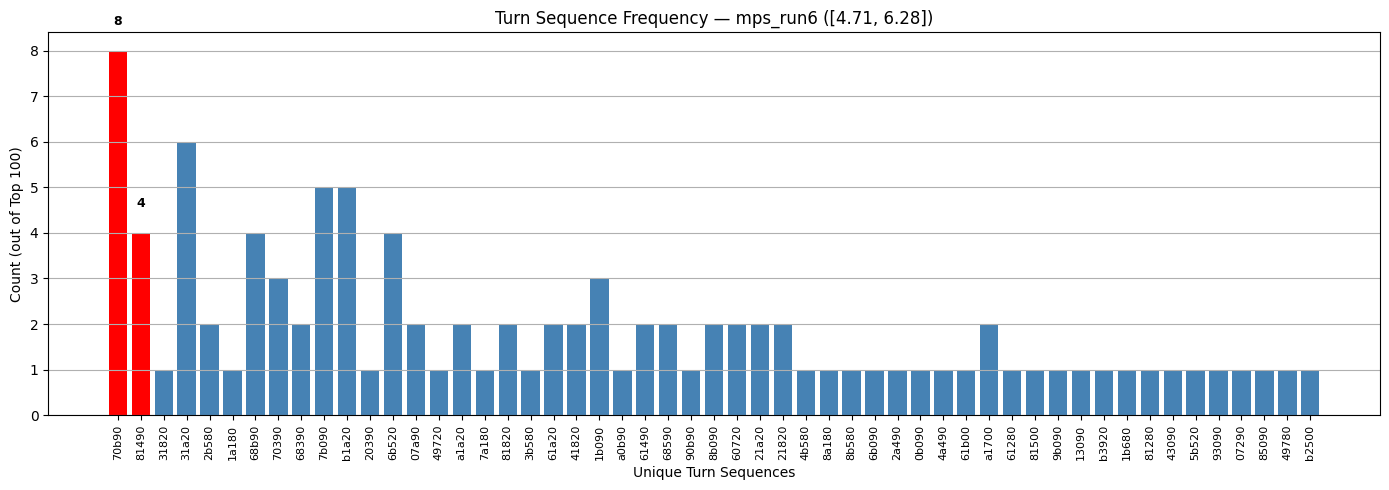

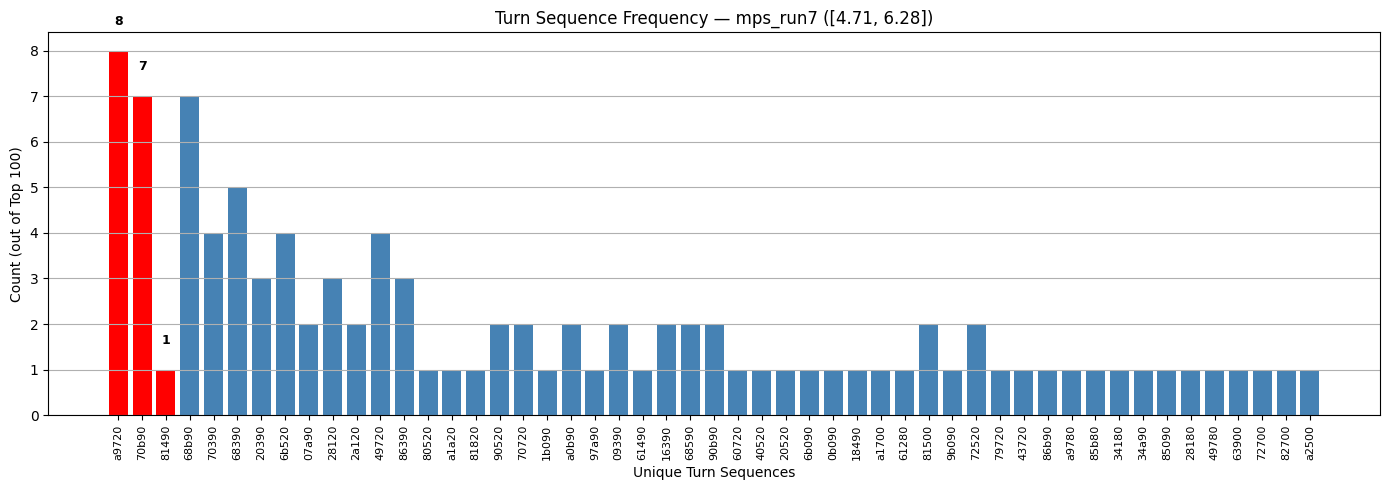

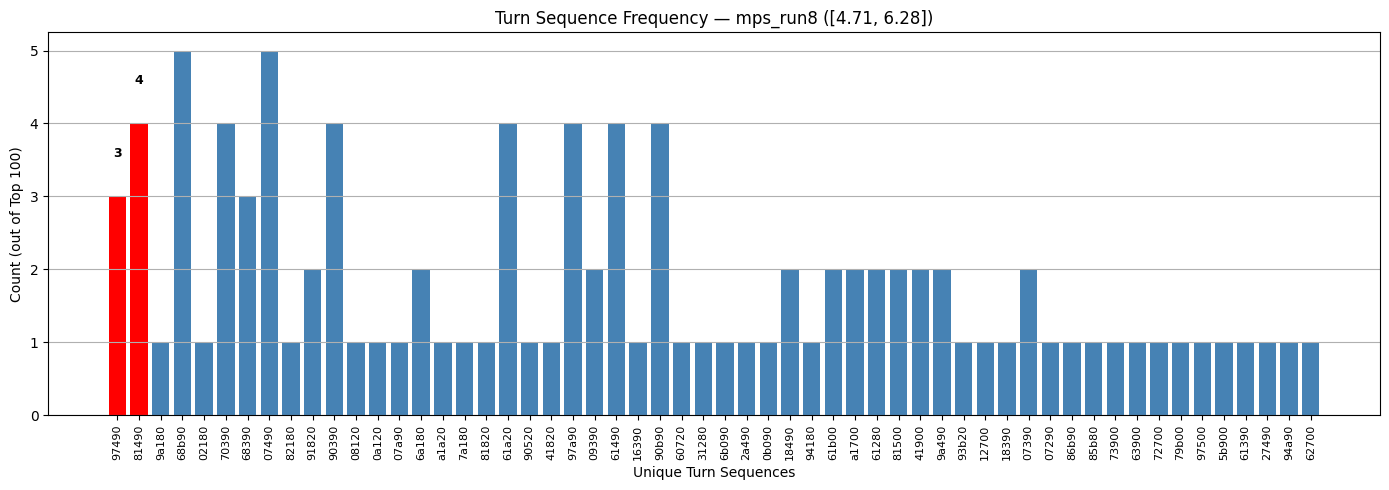

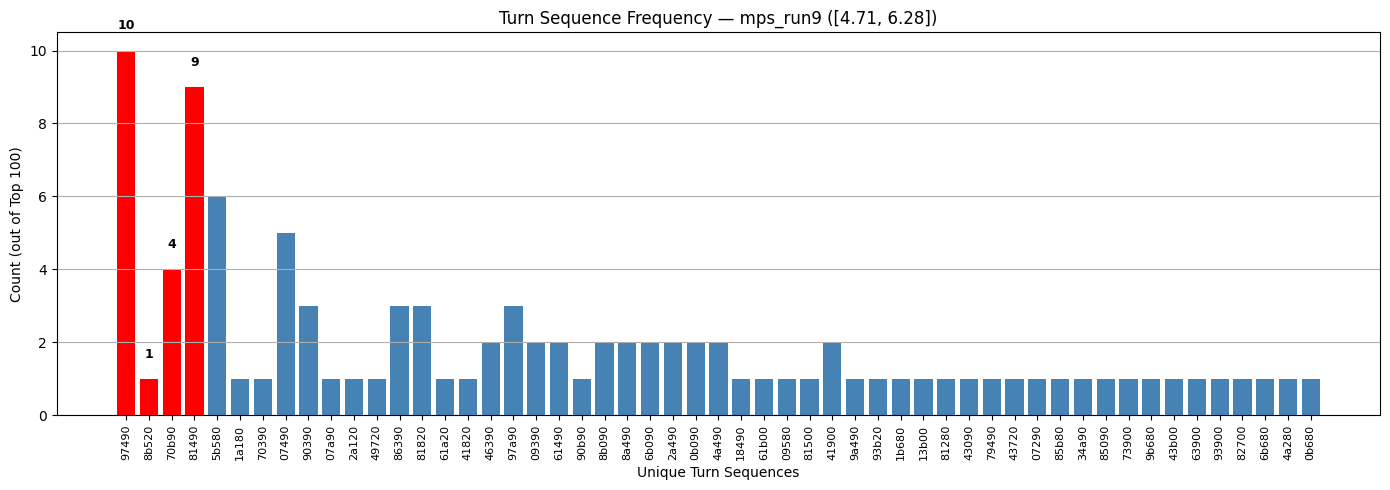

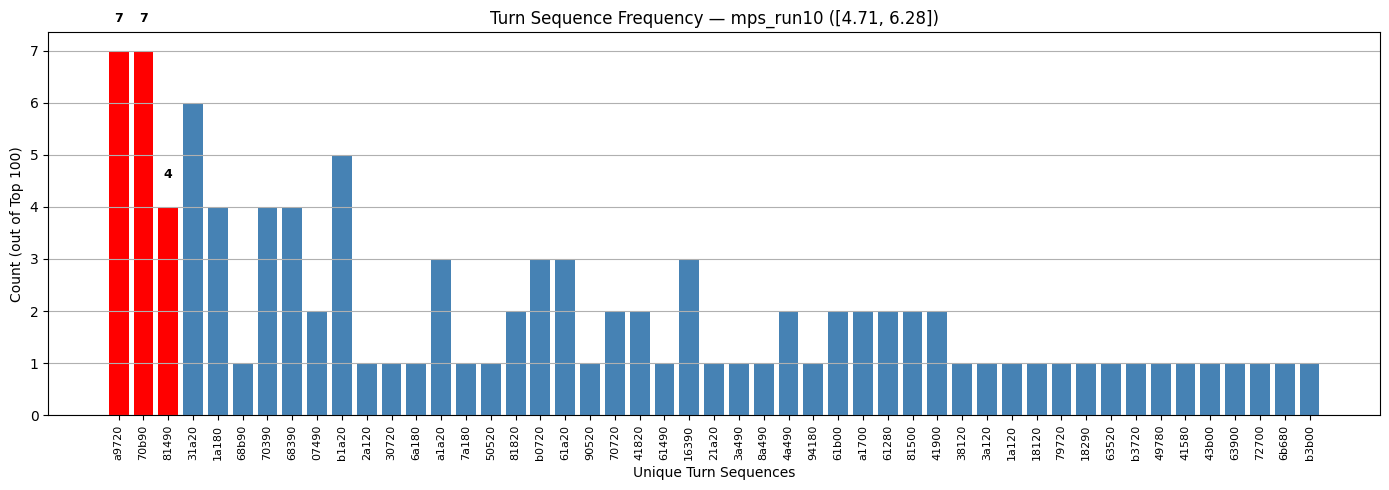

In [22]:
from collections import Counter
import matplotlib.pyplot as plt

# Top 5 classical solutions to highlight
cls_top5 = {'97490', 'a9720', '8b520', '70b90', '81490'}

for i in range(11):
    key = f"mps_run{i}"
    top_mps_solns = top_mps_solns_by_run[key]
    metadata = all_metadata[key]
    
    # Extract turn sequences as strings
    turn_strs = [''.join(sol[0]) for sol in top_mps_solns]
    
    # Compute corrected bitstrings and their energies
    peptide = Peptide(metadata['main_seq'])
    correct_bitstrings = [ProteinShapeDecoder(peptide, sol[1]).correct_bitstring for sol in top_mps_solns]
    energies = [_evaluate_sparsepauli(bitstring, qubit_op) for bitstring in correct_bitstrings]
    
    # Map turn string to its recomputed energy
    bitstring_energy_dict = {turn_strs[j]: energies[j] for j in range(len(turn_strs))}
    
    # Count occurrences
    turn_counts = Counter(turn_strs)
    
    # Sort turn sequences based on ascending energy
    sorted_turns = sorted(turn_counts.keys(), key=lambda x: bitstring_energy_dict[x])

    x_vals = list(range(len(sorted_turns)))
    y_vals = [turn_counts[turn] for turn in sorted_turns]

    # Highlight top-5 CLS solutions
    bar_colors = ['red' if turn in cls_top5 else 'steelblue' for turn in sorted_turns]

    # Plot
    plt.figure(figsize=(14, 5))
    bars = plt.bar(x_vals, y_vals, color=bar_colors)

    # Annotate red bars
    for idx, turn in enumerate(sorted_turns):
        if turn in cls_top5:
            count = turn_counts[turn]
            plt.text(x_vals[idx], y_vals[idx] + 0.5, str(count),
                     ha='center', va='bottom', color='black',
                     fontsize=9, fontweight='bold')

    plt.xticks(ticks=x_vals, labels=sorted_turns, rotation=90, fontsize=8)
    plt.xlabel("Unique Turn Sequences")
    plt.ylabel("Count (out of Top 100)")
    plt.title(f"Turn Sequence Frequency — {key} ({metadata['init_param_interval']})")
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()
